In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Imports**

In [1]:

import os, gc, json, pickle, warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import OneCycleLR
import time
warnings.filterwarnings('ignore')

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


**Configuration**

In [5]:
CFG = dict(
    pkl_train   = '/kaggle/input/datasets/raghavender76/pklfiles/train_data.pkl',
    pkl_val     = '/kaggle/input/datasets/raghavender76/pklfiles/val_data.pkl',
    pkl_test    = '/kaggle/input/datasets/raghavender76/pklfiles/test_data.pkl',
 
    # Top-5 categories from DeepFashion2 (category_id → label index)
    # 1=short sleeve top, 2=long sleeve top, 7=shorts, 8=trousers, 9=skirt
    category_ids   = [1, 2, 7, 8, 9],
    category_names = ['Short Sleeve Top', 'Long Sleeve Top',
                      'Shorts', 'Trousers', 'Skirt'],
 
    img_size    = 224,
    batch_size  = 64,       # 64 fits P100/T4; drop to 32 if OOM
    num_workers = 0,
    pin_memory  = True,
 
    # Training
    epochs      = 15,
    lr          = 3e-4,     # OneCycleLR max_lr
    wd          = 1e-4,
    label_smoothing = 0.05,
 
    # Unfreeze strategy
    unfreeze_epoch = 3,     # after epoch 3 unfreeze last 2 blocks
    unfreeze_lr    = 5e-5,
)
 
NUM_CLASSES = len(CFG['category_ids'])
CAT2IDX     = {c: i for i, c in enumerate(CFG['category_ids'])}

**Load pkl files**

In [6]:
def load_pkl(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    print(f"Loaded {path}  →  type={type(data)},  len={len(data)}")
    return data
 
train_data = load_pkl(CFG['pkl_train'])
val_data   = load_pkl(CFG['pkl_val'])
test_data  = load_pkl(CFG['pkl_test'])
 
# ── Inspect one sample to understand pkl structure ──
sample = train_data[0]
print("\nSample keys:", sample.keys() if hasattr(sample, 'keys') else type(sample))

Loaded /kaggle/input/datasets/raghavender76/pklfiles/train_data.pkl  →  type=<class 'tuple'>,  len=2
Loaded /kaggle/input/datasets/raghavender76/pklfiles/val_data.pkl  →  type=<class 'tuple'>,  len=2
Loaded /kaggle/input/datasets/raghavender76/pklfiles/test_data.pkl  →  type=<class 'tuple'>,  len=2

Sample keys: <class 'list'>


In [6]:
sample = train_data[0]
print(type(sample))
print(len(sample))
print(type(sample[0]), type(sample[1]))  # see what's at each index
# If it's nested, go deeper:
print(sample[0] if not hasattr(sample[0], 'shape') else sample[0].shape)
print(sample[1])

<class 'list'>
122547
<class 'str'> <class 'str'>
/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images/168202.jpg
/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images/125778.jpg


In [7]:
print(type(train_data[0]), len(train_data[0]))   # should be list of paths
print(type(train_data[1]), len(train_data[1]))   # should be list of labels
print(train_data[1][0])                          # see what one label looks like

<class 'list'> 122547
<class 'list'> 122547
[1, 1, 0, 0, 0]


In [7]:
def build_multilabel_vector(cat_ids_in_image):
    """Convert list of category_ids → binary vector of length NUM_CLASSES."""
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    for cid in cat_ids_in_image:
        if cid in CAT2IDX:
            vec[CAT2IDX[cid]] = 1.0
    return vec
 
 
class ApparelDataset(Dataset):
    def __init__(self, data, transform=None):
        self.transform  = transform
        self.img_paths  = data[0]   # list of file paths
        self.labels     = data[1]   # list of [0/1, 0/1, 0/1, 0/1, 0/1]

        print(f"Dataset built: {len(self.img_paths)} samples")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

**Datasets**

In [8]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
train_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'] + 32, CFG['img_size'] + 32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),   # CutOut-style
])
 
val_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
 
train_ds = ApparelDataset(train_data, transform=train_tf)
val_ds   = ApparelDataset(val_data,   transform=val_tf)
test_ds  = ApparelDataset(test_data,  transform=val_tf)
 
del train_data, val_data, test_data
gc.collect()

Dataset built: 122547 samples
Dataset built: 23741 samples
Dataset built: 21627 samples


0

In [9]:
all_labels  = np.array(train_ds.labels, dtype=np.float32)
pos_counts  = all_labels.sum(axis=0)
neg_counts  = len(train_ds) - pos_counts
pos_weights = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(DEVICE)
print("Pos weights:", pos_weights.cpu().numpy().round(2))

Pos weights: [1.04 1.62 2.98 3.04 3.71]


**Data Loaders**

In [10]:
train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'], shuffle=True,
    num_workers=4, pin_memory=CFG['pin_memory'],
    drop_last=True, persistent_workers=True
)
val_loader = DataLoader(
    val_ds, batch_size=CFG['batch_size'] * 2, shuffle=False,
    num_workers=4, pin_memory=CFG['pin_memory'],
    persistent_workers=True
)
test_loader = DataLoader(
    test_ds, batch_size=CFG['batch_size'] * 2, shuffle=False,
    num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory']
)
print(f"\nBatches — train: {len(train_loader)} | val: {len(val_loader)}")


Batches — train: 1914 | val: 186


In [11]:
class EfficientNetB0Classifier(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
 
        # Freeze all initially
        for p in base.parameters():
            p.requires_grad = False
 
        self.features   = base.features       # CNN backbone
        self.avgpool    = base.avgpool
        in_features     = base.classifier[1].in_features  # 1280
 
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes),
        )
        # Note: NO sigmoid here — BCEWithLogitsLoss applies it internally
 
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)
 
    def unfreeze_last_blocks(self, n=2):
        """Unfreeze last n feature blocks for fine-tuning."""
        blocks = list(self.features.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        print(f"Unfrozen last {n} feature blocks.")
 
 
model = EfficientNetB0Classifier(num_classes=NUM_CLASSES).to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s] 


**Loss ,Criterion**

In [12]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
 
# Only train classifier head initially
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'], weight_decay=CFG['wd']
)
 
scheduler = OneCycleLR(
    optimizer,
    max_lr=CFG['lr'],
    epochs=CFG['epochs'],
    steps_per_epoch=len(train_loader),
    pct_start=0.2,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100,
)
 
scaler = GradScaler()

**Helper Functions**

In [13]:
def find_best_thresholds(probs, targets, n_thresh=50):
    thresholds = np.linspace(0.2, 0.8, n_thresh)
    best_t = []
    for i in range(NUM_CLASSES):
        best_f1, best_th = 0, 0.5
        for t in thresholds:
            preds = (probs[:, i] >= t).astype(int)
            f1 = f1_score(targets[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_th = f1, t
        best_t.append(best_th)
    return np.array(best_t)

In [14]:
def train_one_epoch(loader):
    model.train()
    total_loss = 0
    t0 = time.time()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
    elapsed = time.time() - t0
    return total_loss / len(loader), elapsed
 
 
@torch.no_grad()
def evaluate(loader, thresholds=None):
    model.eval()
    all_probs, all_targets = [], []
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(labels.cpu().numpy())
        total_loss += loss.item()
 
    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    avg_loss    = total_loss / len(loader)
 
    if thresholds is None:
        thresholds = np.full(NUM_CLASSES, 0.5)
 
    preds = (all_probs >= thresholds).astype(int)
 
    macro_f1 = f1_score(all_targets, preds, average='macro', zero_division=0)
    micro_f1 = f1_score(all_targets, preds, average='micro', zero_division=0)
 
    return avg_loss, macro_f1, micro_f1, all_probs, all_targets

**Transfer learning model and training loops**

In [17]:
# ============================================================
# TRANSFER — EfficientNet-B0 (ImageNet pretrained weights)
# ============================================================
import time
from tqdm.notebook import tqdm

class TransferModel(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        # Freeze all backbone layers initially
        for p in base.parameters():
            p.requires_grad = False
        self.features   = base.features
        self.avgpool    = base.avgpool
        in_features     = base.classifier[1].in_features
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)
    def unfreeze_last_blocks(self, n=3):
        blocks = list(self.features.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        print(f"Unfrozen last {n} blocks.", flush=True)

transfer_model = TransferModel(NUM_CLASSES).to(DEVICE)

# Only classifier trainable initially
transfer_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, transfer_model.parameters()),
    lr=3e-4, weight_decay=1e-4
)
transfer_scheduler = OneCycleLR(
    transfer_optimizer, max_lr=3e-4,
    epochs=10, steps_per_epoch=len(train_loader),
    pct_start=0.2, anneal_strategy='cos',
    div_factor=10, final_div_factor=100,
)
transfer_scaler = GradScaler()

TRANSFER_EPOCHS    = 10
UNFREEZE_EPOCH     = 3
transfer_history   = {'train_loss': [], 'val_loss': [], 'macro_f1': [], 'micro_f1': []}
best_transfer_f1   = 0.0
best_transfer_thresholds = np.full(NUM_CLASSES, 0.5)

print("="*65)
print("MODE: TRANSFER LEARNING")
print(f"{'Ep':>3} {'TrainLoss':>10} {'ValLoss':>9} {'MacroF1':>9} {'MicroF1':>9} {'Time':>7}")
print("="*65, flush=True)

for epoch in range(1, TRANSFER_EPOCHS + 1):

    # Unfreeze last 3 blocks after warm-up
    if epoch == UNFREEZE_EPOCH:
        transfer_model.unfreeze_last_blocks(n=3)
        transfer_optimizer = torch.optim.AdamW([
            {'params': filter(lambda p: p.requires_grad,
                              transfer_model.features.parameters()),
             'lr': 5e-5},
            {'params': transfer_model.classifier.parameters(),
             'lr': 3e-4},
        ], weight_decay=1e-4)
        transfer_scheduler = OneCycleLR(
            transfer_optimizer,
            max_lr=[5e-5, 3e-4],
            epochs=TRANSFER_EPOCHS - epoch + 1,
            steps_per_epoch=len(train_loader),
            pct_start=0.1, anneal_strategy='cos',
        )

    transfer_model.train()
    total_loss = 0
    t0   = time.time()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{TRANSFER_EPOCHS} [Transfer]", leave=False)

    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        transfer_optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = transfer_model(imgs)
            loss   = criterion(logits, labels)
        transfer_scaler.scale(loss).backward()
        transfer_scaler.unscale_(transfer_optimizer)
        torch.nn.utils.clip_grad_norm_(transfer_model.parameters(), 1.0)
        transfer_scaler.step(transfer_optimizer)
        transfer_scaler.update()
        transfer_scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss = total_loss / len(train_loader)
    elapsed    = time.time() - t0

    # Validate
    transfer_model.eval()
    all_probs, all_targets = [], []
    val_loss_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with autocast():
                logits = transfer_model(imgs)
                loss   = criterion(logits, labels)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_targets.append(labels.cpu().numpy())
            val_loss_total += loss.item()

    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    val_loss    = val_loss_total / len(val_loader)
    thresholds  = find_best_thresholds(all_probs, all_targets)
    preds       = (all_probs >= thresholds).astype(int)
    macro_f1    = f1_score(all_targets, preds, average='macro', zero_division=0)
    micro_f1    = f1_score(all_targets, preds, average='micro', zero_division=0)

    transfer_history['train_loss'].append(train_loss)
    transfer_history['val_loss'].append(val_loss)
    transfer_history['macro_f1'].append(macro_f1)
    transfer_history['micro_f1'].append(micro_f1)

    flag = ' ◀ best' if macro_f1 > best_transfer_f1 else ''
    print(f"{epoch:>3} {train_loss:>10.4f} {val_loss:>9.4f} "
          f"{macro_f1:>9.4f} {micro_f1:>9.4f} {elapsed:>6.1f}s{flag}", flush=True)

    if macro_f1 > best_transfer_f1:
        best_transfer_f1         = macro_f1
        best_transfer_thresholds = thresholds
        torch.save({
            'model_state': transfer_model.state_dict(),
            'thresholds':  best_transfer_thresholds,
            'macro_f1':    best_transfer_f1,
        }, '/kaggle/working/best_efficientnet_b0_transfer.pth')

print(f"\nBest Transfer Val Macro F1: {best_transfer_f1:.4f}", flush=True)

MODE: TRANSFER LEARNING
 Ep  TrainLoss   ValLoss   MacroF1   MicroF1    Time


Epoch 1/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

  1     0.8496    0.7632    0.6122    0.6435 1045.3s ◀ best


Epoch 2/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

  2     0.7961    0.7370    0.6216    0.6540  682.0s ◀ best
Unfrozen last 3 blocks.


...

  8     0.4208    0.3856    0.8214    0.8373  685.9s ◀ best


Epoch 9/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

  9     0.4117    0.3860    0.8224    0.8386  688.7s ◀ best


Epoch 10/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

 10     0.4088    0.3855    0.8214    0.8376  685.9s

Best Transfer Val Macro F1: 0.8224


**Evaluation metrics**


PER-CLASS EVALUATION REPORT: EFFICIENTNET-B0 TRANSFER

Category ID: 1 (Short Sleeve Top)
  Precision: 0.7968
  Recall:    0.8866
  F1-Score:  0.8393
  AUC:       0.9208

Category ID: 2 (Long Sleeve Top)
  Precision: 0.9288
  Recall:    0.9105
  F1-Score:  0.9196
  AUC:       0.9851

Category ID: 7 (Shorts)
  Precision: 0.8852
  Recall:    0.8383
  F1-Score:  0.8611
  AUC:       0.9755

Category ID: 8 (Trousers)
  Precision: 0.7240
  Recall:    0.7860
  F1-Score:  0.7537
  AUC:       0.9316

Category ID: 9 (Skirt)
  Precision: 0.7806
  Recall:    0.7987
  F1-Score:  0.7895
  AUC:       0.9571

───────────────────────────────────────────────────────
Macro-Averaged F1: 0.8327
Micro-Averaged F1: 0.8410
───────────────────────────────────────────────────────


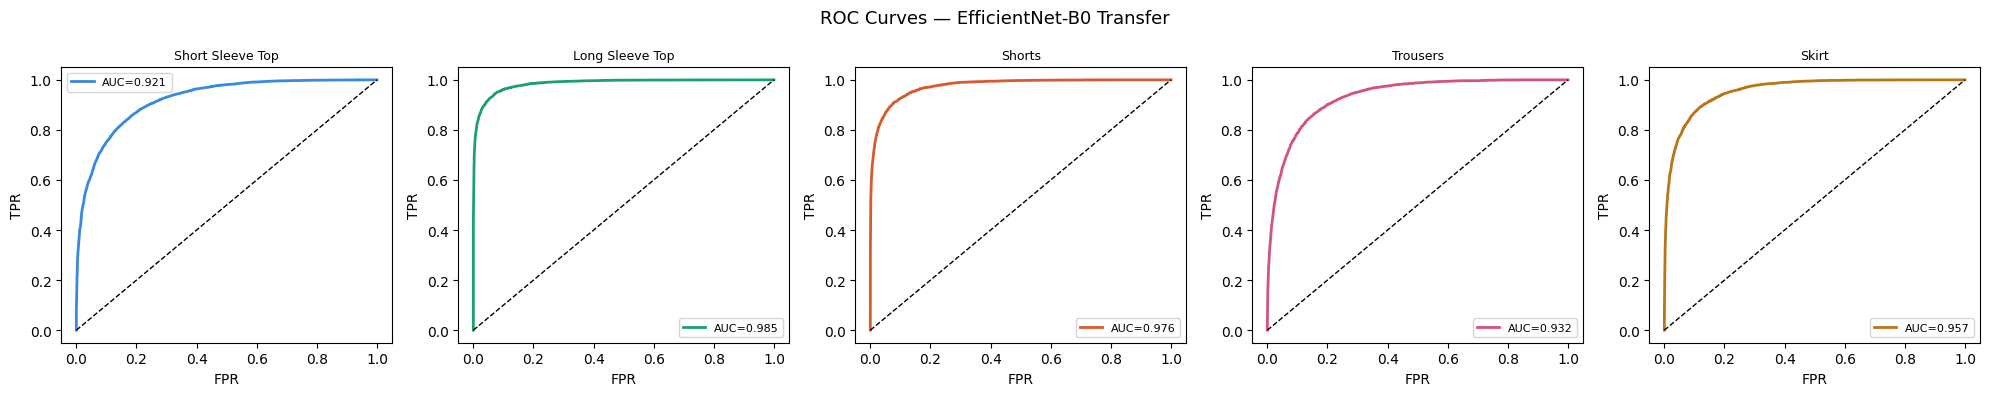

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from torch.cuda.amp import autocast


# =========================
# LOAD MODEL
# =========================
ckpt = torch.load(
    '/kaggle/input/datasets/raghavender76/tlvepth/best_efficientnet_b0_transfer.pth',weights_only=False,
    map_location=DEVICE
)

model.load_state_dict(ckpt['model_state'])
model.eval()


# =========================
# EVALUATION
# =========================
@torch.no_grad()
def evaluate_model(loader):
    all_probs, all_targets = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(imgs)

        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(labels.cpu().numpy())

    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    return all_probs, all_targets


# =========================
# FIND THRESHOLDS (SILENT)
# =========================
def find_best_thresholds(probs, targets):
    thresholds = []

    for i in range(NUM_CLASSES):
        best_f1 = 0
        best_t = 0.5

        for t in np.linspace(0.2, 0.8, 20):  # reduced for speed
            preds = (probs[:, i] >= t).astype(int)
            f1 = f1_score(targets[:, i], preds, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    return np.array(thresholds)


# =========================
# RUN EVALUATION
# =========================
all_probs, all_targets = evaluate_model(test_loader)

thresholds = find_best_thresholds(all_probs, all_targets)

preds = (all_probs >= thresholds).astype(int)


# =========================
# METRICS
# =========================
category_ids   = CFG['category_ids']
category_names = CFG['category_names']

print("\n=======================================================")
print("PER-CLASS EVALUATION REPORT: EFFICIENTNET-B0 TRANSFER")
print("=======================================================")

for i, (cid, name) in enumerate(zip(category_ids, category_names)):

    prec = precision_score(all_targets[:, i], preds[:, i], zero_division=0)
    rec  = recall_score(all_targets[:, i], preds[:, i], zero_division=0)
    f1   = f1_score(all_targets[:, i], preds[:, i], zero_division=0)

    try:
        auc = roc_auc_score(all_targets[:, i], all_probs[:, i])
    except:
        auc = float('nan')

    print(f"\nCategory ID: {cid} ({name})")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")


# =========================
# OVERALL METRICS
# =========================
macro_f1 = f1_score(all_targets, preds, average='macro', zero_division=0)
micro_f1 = f1_score(all_targets, preds, average='micro', zero_division=0)

print(f"\n{'─'*55}")
print(f"Macro-Averaged F1: {macro_f1:.4f}")
print(f"Micro-Averaged F1: {micro_f1:.4f}")
print(f"{'─'*55}")


# =========================
# ROC CURVES
# =========================
colors = ['#378ADD', '#1D9E75', '#D85A30', '#D4537E', '#BA7517']

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))

for i, (name, ax, color) in enumerate(zip(category_names, axes, colors)):
    try:
        fpr, tpr, _ = roc_curve(all_targets[:, i], all_probs[:, i])
        auc = roc_auc_score(all_targets[:, i], all_probs[:, i])

        ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC={auc:.3f}')
    except:
        continue

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves — EfficientNet-B0 Transfer', fontsize=13)
plt.tight_layout()

plt.savefig('/kaggle/working/roc_efficientnet_transfer.png', dpi=150)
plt.show()